# Phase 1 — PRISM Data Exploration & Long-Tail Analysis

## Objective

Establish the feasibility of the PRISM dataset for pancreatic cancer drug-response prediction and characterize the response distribution before modeling.

### Questions addressed
1. How many PRISM cell lines are available?
2. How many are pancreatic cancer cell lines?
3. How many PRISM response records are available for pancreatic cancer?
4. How many finite IC50 observations and drugs are available?
5. What does the log10(IC50) distribution look like?
6. Are extreme fitted IC50 values associated with poorer dose-response curve-fit quality (R²)?

**Important:** Extreme IC50 values are not automatically treated as noise. This phase only characterizes their distribution and relationship with curve-fit quality.

## 1. Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

## 2. Set project paths

The raw PRISM files are stored in `data/raw`.


In [2]:
PROJECT_ROOT = Path(r"D:\Pancreatic_GraphTCDR")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

CELL_INFO_FILE = RAW_DIR / "secondary-screen-cell-line-info.csv"
RESPONSE_FILE = RAW_DIR / "secondary-screen-dose-response-curve-parameters.csv"

print("Project:", PROJECT_ROOT)
print("Cell info exists:", CELL_INFO_FILE.exists())
print("Response file exists:", RESPONSE_FILE.exists())

Project: D:\Pancreatic_GraphTCDR
Cell info exists: True
Response file exists: True


## 3. Load PRISM cell-line metadata

In [3]:
cell_info = pd.read_csv(CELL_INFO_FILE)

print("Shape:", cell_info.shape)
print("Columns:", cell_info.columns.tolist())
display(cell_info.head())

Shape: (588, 7)
Columns: ['row_name', 'depmap_id', 'ccle_name', 'primary_tissue', 'secondary_tissue', 'tertiary_tissue', 'passed_str_profiling']


,row_name,depmap_id,ccle_name,primary_tissue,secondary_tissue,tertiary_tissue,passed_str_profiling
0,ACH-000824,ACH-000824,KYSE510_OESOPHAGUS,esophagus,esophagus_squamous,NaN,True
1,ACH-000954,ACH-000954,HEC1A_ENDOMETRIUM,uterus,uterus_endometrium,NaN,True
2,ACH-000601,ACH-000601,MIAPACA2_PANCREAS,pancreas,NaN,NaN,True
3,ACH-000651,ACH-000651,SW620_LARGE_INTESTINE,colorectal,NaN,NaN,True
4,ACH-000361,ACH-000361,SKHEP1_LIVER,liver,NaN,NaN,True


## 4. Identify pancreatic cancer cell lines

PRISM contains multiple cancer types. We select rows whose `primary_tissue` is pancreatic.

In [4]:
print(cell_info["primary_tissue"].value_counts(dropna=False).head(20))

pancreatic_cells = cell_info[
    cell_info["primary_tissue"].astype(str).str.upper().eq("PANCREAS")
].copy()

print("Pancreatic cell lines:", len(pancreatic_cells))
display(pancreatic_cells[["row_name", "depmap_id", "ccle_name", "primary_tissue"]].head(50))


primary_tissue
lung                         105
central_nervous_system        43
skin                          43
ovary                         40
pancreas                      37
colorectal                    35
upper_aerodigestive           28
breast                        27
esophagus                     24
urinary_tract                 24
bone                          23
uterus                        23
liver                         21
gastric                       21
kidney                        19
rhabdoid                      12
peripheral_nervous_system     12
thyroid                       11
NaN                           10
mesothelioma                   9
Name: count, dtype: int64
Pancreatic cell lines: 37


,row_name,depmap_id,ccle_name,primary_tissue
2,ACH-000601,ACH-000601,MIAPACA2_PANCREAS,pancreas
15,ACH-000332,ACH-000332,YAPC_PANCREAS,pancreas
19,ACH-000178,ACH-000178,HS766T_PANCREAS,pancreas
28,ACH-000108,ACH-000108,KP3_PANCREAS,pancreas
38,ACH-000164,ACH-000164,PANC1_PANCREAS,pancreas
59,ACH-000599,ACH-000599,PATU8902_PANCREAS,pancreas
61,ACH-000347,ACH-000347,QGP1_PANCREAS,pancreas
104,ACH-000307,ACH-000307,PK1_PANCREAS,pancreas
117,ACH-000205,ACH-000205,PK59_PANCREAS,pancreas
124,ACH-000243,ACH-000243,DANG_PANCREAS,pancreas


## 5. Store the pancreatic cell-line identifiers

These identifiers will be used to select the corresponding response records from the PRISM response table.

In [5]:
pancreatic_depmap_ids = pancreatic_cells["depmap_id"].dropna().astype(str).unique().tolist()

print("Number of pancreatic DepMap IDs:", len(pancreatic_depmap_ids))
print(pancreatic_depmap_ids)

Number of pancreatic DepMap IDs: 37
['ACH-000601', 'ACH-000332', 'ACH-000178', 'ACH-000108', 'ACH-000164', 'ACH-000599', 'ACH-000347', 'ACH-000307', 'ACH-000205', 'ACH-000243', 'ACH-000022', 'ACH-000155', 'ACH-000042', 'ACH-000468', 'ACH-000270', 'ACH-000535', 'ACH-000281', 'ACH-000023', 'ACH-000652', 'ACH-000320', 'ACH-000138', 'ACH-000118', 'ACH-000235', 'ACH-000266', 'ACH-000222', 'ACH-000139', 'ACH-000107', 'ACH-000502', 'ACH-000517', 'ACH-000417', 'ACH-000060', 'ACH-000265', 'ACH-000685', 'ACH-000213', 'ACH-000093', 'ACH-000114', 'ACH-000085']


## 6. Load PRISM dose-response data

This is the large response file. It contains fitted dose-response parameters such as IC50, AUC and R².

In [6]:
response = pd.read_csv(RESPONSE_FILE, low_memory=False)

print("Shape:", response.shape)
print("Columns:", response.columns.tolist())
display(response.head())

Shape: (701004, 20)
Columns: ['broad_id', 'depmap_id', 'ccle_name', 'screen_id', 'upper_limit', 'lower_limit', 'slope', 'r2', 'auc', 'ec50', 'ic50', 'name', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase', 'passed_str_profiling', 'row_name']


,broad_id,depmap_id,ccle_name,screen_id,upper_limit,lower_limit,slope,r2,auc,ec50,ic50,name,moa,target,disease.area,indication,smiles,phase,passed_str_profiling,row_name
0,BRD-K71847383-001-12-5,ACH-000879,MFE296_ENDOMETRIUM,HTS002,1,2.122352,-0.022826,-0.026964,1.677789,8.415093e+06,NaN,cytarabine,ribonucleotide reductase inhibitor,"POLA1, POLB, POLD1, POLE",hematologic malignancy,"acute lymphoblastic leukemia (ALL), chronic ly...",Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)...,Launched,True,ACH-000879
1,BRD-K71847383-001-12-5,ACH-000320,PSN1_PANCREAS,HTS002,1,1.325174,-0.237504,-0.147274,1.240300,9.643742e+00,NaN,cytarabine,ribonucleotide reductase inhibitor,"POLA1, POLB, POLD1, POLE",hematologic malignancy,"acute lymphoblastic leukemia (ALL), chronic ly...",Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)...,Launched,True,ACH-000320
2,BRD-K71847383-001-12-5,ACH-001145,OC316_OVARY,HTS002,1,2.089350,-0.302937,0.193893,1.472333,2.776687e-02,NaN,cytarabine,ribonucleotide reductase inhibitor,"POLA1, POLB, POLD1, POLE",hematologic malignancy,"acute lymphoblastic leukemia (ALL), chronic ly...",Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)...,Launched,True,ACH-001145
3,BRD-K71847383-001-12-5,ACH-000873,KYSE270_OESOPHAGUS,HTS002,1,1.311820,-0.209393,-0.005460,1.207160,2.654701e+00,NaN,cytarabine,ribonucleotide reductase inhibitor,"POLA1, POLB, POLD1, POLE",hematologic malignancy,"acute lymphoblastic leukemia (ALL), chronic ly...",Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)...,Launched,True,ACH-000873
4,BRD-K71847383-001-12-5,ACH-000855,KYSE150_OESOPHAGUS,HTS002,1,1.369799,-0.277530,0.132818,1.229332,5.889041e-01,NaN,cytarabine,ribonucleotide reductase inhibitor,"POLA1, POLB, POLD1, POLE",hematologic malignancy,"acute lymphoblastic leukemia (ALL), chronic ly...",Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)...,Launched,True,ACH-000855


## 7. Extract the pancreatic subset

pancreatic_response = response[
    response["depmap_id"].astype(str).isin(pancreatic_depmap_ids)
].copy()

print("Pancreatic response shape:", pancreatic_response.shape)
print("Unique pancreatic cell lines:", pancreatic_response["depmap_id"].nunique())
print("Unique raw drugs:", pancreatic_response["name"].nunique())

display(
    pancreatic_response[
        ["depmap_id", "ccle_name", "name", "ic50", "r2", "auc", "smiles"]
    ].head()
)


## 8. Check IC50 availability

We distinguish missing IC50 values, finite IC50 values and infinite values.

ic50_numeric = pd.to_numeric(pancreatic_response["ic50"], errors="coerce")

print("Total pancreatic records:", len(pancreatic_response))
print("Missing/non-numeric IC50:", ic50_numeric.isna().sum())
print("Finite IC50:", np.isfinite(ic50_numeric).sum())
print("Infinite IC50:", np.isinf(ic50_numeric).sum())

pancreatic_response["ic50_numeric"] = ic50_numeric

## 9. Create the finite-IC50 analysis table

In [8]:
# Create the pancreatic PRISM response table

pancreatic_response = response[
    response["depmap_id"].isin(pancreatic_depmap_ids)
].copy()

print("Pancreatic response shape:", pancreatic_response.shape)
print("Unique cell lines:", pancreatic_response["depmap_id"].nunique())

Pancreatic response shape: (47087, 20)
Unique cell lines: 33


In [10]:
# Create numeric IC50 values

pancreatic_response["ic50_numeric"] = pd.to_numeric(
    pancreatic_response["ic50"],
    errors="coerce"
)

finite_ic50 = pancreatic_response[
    np.isfinite(pancreatic_response["ic50_numeric"])
].copy()

finite_ic50["log_ic50"] = np.log10(
    finite_ic50["ic50_numeric"]
)

print("Finite IC50 observations:", len(finite_ic50))
print("Unique drugs:", finite_ic50["name"].nunique())
print("Unique cell lines:", finite_ic50["depmap_id"].nunique())

Finite IC50 observations: 22676
Unique drugs: 1246
Unique cell lines: 33


In [11]:
finite_ic50 = pancreatic_response[
    np.isfinite(pancreatic_response["ic50_numeric"])
].copy()

finite_ic50["log_ic50"] = np.log10(finite_ic50["ic50_numeric"])

print("Finite IC50 observations:", len(finite_ic50))
print("Unique drugs:", finite_ic50["name"].nunique())
print("Unique cell lines:", finite_ic50["depmap_id"].nunique())

Finite IC50 observations: 22676
Unique drugs: 1246
Unique cell lines: 33


## 10. Check SMILES coverage for usable IC50 observations

In [12]:
smiles_available = finite_ic50["smiles"].notna() & (
    finite_ic50["smiles"].astype(str).str.strip() != ""
)

print("Finite IC50 observations:", len(finite_ic50))
print("With SMILES:", smiles_available.sum())
print("Without SMILES:", (~smiles_available).sum())
print("SMILES coverage: {:.2f}%".format(100 * smiles_available.mean()))


Finite IC50 observations: 22676
With SMILES: 22676
Without SMILES: 0
SMILES coverage: 100.00%


## 11. Summarize the log10(IC50) distribution

In [13]:
log_ic50_summary = finite_ic50["log_ic50"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(log_ic50_summary)


count    22676.000000
mean        -0.008015
std          2.973072
min       -110.746563
1%          -3.172144
5%          -1.709026
10%         -1.192728
25%         -0.352672
50%          0.193697
75%          0.510974
90%          0.775614
95%          0.869512
99%          1.212704
max        287.762339
Name: log_ic50, dtype: float64

## 12. Count observations across response ranges

We use log10(IC50) ranges to examine the central region and the tails.

In [14]:
bins = [-np.inf, -3, -2, -1, 0, 1, 2, 3, np.inf]
labels = ["< -3", "-3 to -2", "-2 to -1", "-1 to 0",
          "0 to 1", "1 to 2", "2 to 3", "> 3"]

finite_ic50["response_range"] = pd.cut(
    finite_ic50["log_ic50"],
    bins=bins,
    labels=labels,
    right=False
)

range_counts = (
    finite_ic50["response_range"]
    .value_counts(sort=False)
    .rename("count")
    .to_frame()
)

range_counts["percentage"] = 100 * range_counts["count"] / len(finite_ic50)

display(range_counts)

,count,percentage
response_range,,
< -3,268,1.181866
-3 to -2,529,2.332863
-2 to -1,1927,8.497971
-1 to 0,6303,27.795908
0 to 1,13275,58.542071
1 to 2,251,1.106897
2 to 3,39,0.171988
> 3,84,0.370436


## 13. Quantify the extreme tails

In [15]:
extreme_mask = (finite_ic50["log_ic50"] < -3) | (finite_ic50["log_ic50"] > 3)

lower_tail = finite_ic50["log_ic50"] < -3
upper_tail = finite_ic50["log_ic50"] > 3

print("Lower tail (< -3):", lower_tail.sum())
print("Upper tail (> 3):", upper_tail.sum())
print("Total beyond ±3:", extreme_mask.sum())
print("Percentage beyond ±3: {:.2f}%".format(100 * extreme_mask.mean()))

Lower tail (< -3): 268
Upper tail (> 3): 84
Total beyond ±3: 352
Percentage beyond ±3: 1.55%


## 14. Plot the full log10(IC50) distribution

The full distribution shows the extreme fitted values. Because the range is very wide, a second zoomed plot is also created

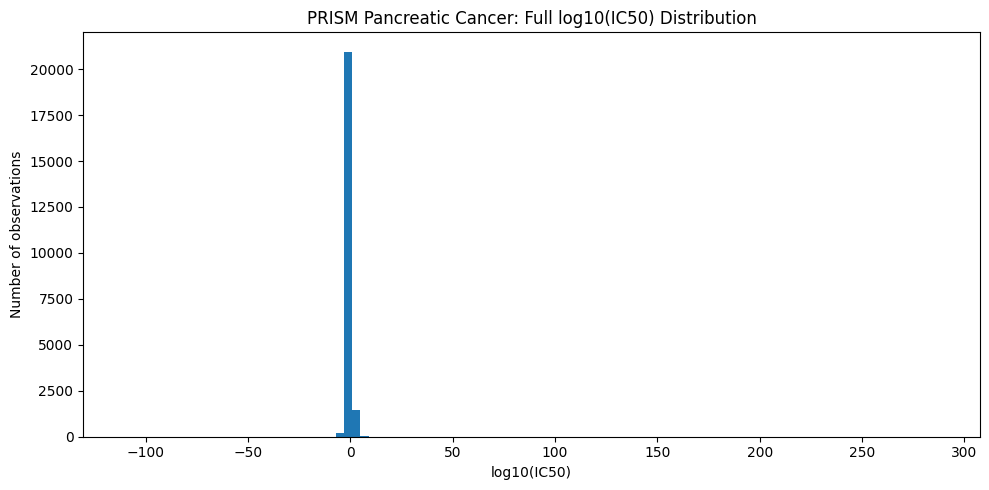

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase1_log_ic50_full.png


In [16]:
plt.figure(figsize=(10, 5))
plt.hist(finite_ic50["log_ic50"], bins=100)
plt.xlabel("log10(IC50)")
plt.ylabel("Number of observations")
plt.title("PRISM Pancreatic Cancer: Full log10(IC50) Distribution")
plt.tight_layout()

full_hist_path = FIGURES_DIR / "phase1_log_ic50_full.png"
plt.savefig(full_hist_path, dpi=300)
plt.show()

print("Saved:", full_hist_path)

## 15. Plot the central distribution and tails

This zoomed view makes the main response distribution easier to inspect.

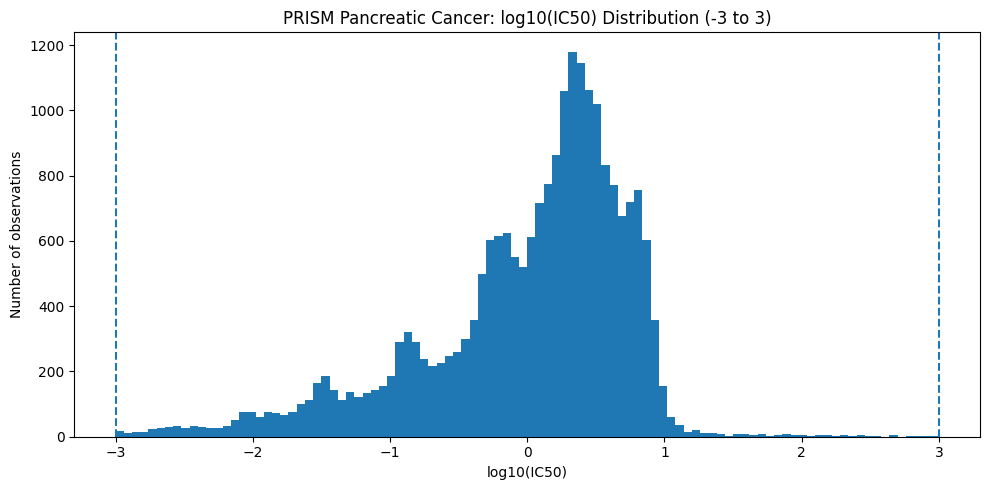

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase1_log_ic50_zoomed.png


In [17]:
plt.figure(figsize=(10, 5))
plt.hist(
    finite_ic50["log_ic50"],
    bins=100,
    range=(-3, 3)
)
plt.axvline(-3, linestyle="--")
plt.axvline(3, linestyle="--")
plt.xlabel("log10(IC50)")
plt.ylabel("Number of observations")
plt.title("PRISM Pancreatic Cancer: log10(IC50) Distribution (-3 to 3)")
plt.tight_layout()

zoom_hist_path = FIGURES_DIR / "phase1_log_ic50_zoomed.png"
plt.savefig(zoom_hist_path, dpi=300)
plt.show()

print("Saved:", zoom_hist_path)

## 16. Examine curve-fit quality across response ranges

PRISM provides `r2` for the dose-response curve fit. We compare the median and mean R² across log10(IC50) ranges.

**Interpretation:** a lower R² indicates poorer agreement between the fitted curve and the observed dose-response data.

In [18]:
finite_ic50["r2_numeric"] = pd.to_numeric(
    finite_ic50["r2"], errors="coerce"
)

quality_by_range = (
    finite_ic50
    .groupby("response_range", observed=False)["r2_numeric"]
    .agg(["count", "median", "mean"])
)

display(quality_by_range)

,count,median,mean
response_range,,,
< -3,268,0.108257,0.227288
-3 to -2,529,0.773557,0.697704
-2 to -1,1927,0.741495,0.693301
-1 to 0,6303,0.615814,0.582842
0 to 1,13275,0.414228,0.383662
1 to 2,251,0.137076,0.155493
2 to 3,39,0.003932,-0.364173
> 3,84,-0.023331,-0.045455


## 17. Calculate the percentage of poor-quality fits in each response range

Two simple indicators are shown:
- R² < 0
- R² < 0.2

These are descriptive thresholds used to characterize the dataset, not to automatically remove observations.

In [19]:
quality_by_range_extended = (
    finite_ic50
    .groupby("response_range", observed=False)
    .agg(
        count=("r2_numeric", "size"),
        median_r2=("r2_numeric", "median"),
        mean_r2=("r2_numeric", "mean"),
        pct_r2_below_0=("r2_numeric", lambda x: 100 * (x < 0).mean()),
        pct_r2_below_02=("r2_numeric", lambda x: 100 * (x < 0.2).mean()),
    )
)

display(quality_by_range_extended)

,count,median_r2,mean_r2,pct_r2_below_0,pct_r2_below_02
response_range,,,,,
< -3,268,0.108257,0.227288,35.820896,54.477612
-3 to -2,529,0.773557,0.697704,3.213611,6.805293
-2 to -1,1927,0.741495,0.693301,1.089777,3.528801
-1 to 0,6303,0.615814,0.582842,1.523084,6.219261
0 to 1,13275,0.414228,0.383662,8.572505,22.252354
1 to 2,251,0.137076,0.155493,27.091633,57.768924
2 to 3,39,0.003932,-0.364173,48.717949,74.358974
> 3,84,-0.023331,-0.045455,63.095238,96.428571


## 18. Save the Phase 1 response-range quality table

In [20]:
quality_table_path = TABLES_DIR / "phase1_response_range_quality.csv"
quality_by_range_extended.to_csv(quality_table_path)

print("Saved:", quality_table_path)

Saved: D:\Pancreatic_GraphTCDR\results\tables\phase1_response_range_quality.csv


## 19. Check the relationship between response magnitude and curve-fit quality

We inspect the association between absolute log10(IC50) magnitude and R². This is descriptive and does not imply causation.

quality_pair = finite_ic50[["log_ic50", "r2_numeric"]].dropna().copy()
quality_pair["abs_log_ic50"] = quality_pair["log_ic50"].abs()

pearson_abs = pearsonr(
    quality_pair["abs_log_ic50"],
    quality_pair["r2_numeric"]
)[0]

spearman_abs = spearmanr(
    quality_pair["abs_log_ic50"],
    quality_pair["r2_numeric"]
)[0]

print("Pearson correlation |log10(IC50)| vs R²:", pearson_abs)
print("Spearman correlation |log10(IC50)| vs R²:", spearman_abs)

## 20. Save the finite pancreatic IC50 analysis table

This table preserves the response information needed for later integration and quality-aware analysis.

In [21]:
phase1_output = finite_ic50[
    [
        "depmap_id",
        "ccle_name",
        "name",
        "ic50_numeric",
        "log_ic50",
        "r2_numeric",
        "auc",
        "smiles"
    ]
].copy()

phase1_output_path = TABLES_DIR / "phase1_pancreatic_finite_ic50.csv"
phase1_output.to_csv(phase1_output_path, index=False)

print("Saved:", phase1_output_path)
print("Shape:", phase1_output.shape)

Saved: D:\Pancreatic_GraphTCDR\results\tables\phase1_pancreatic_finite_ic50.csv
Shape: (22676, 8)


# Phase 1 Summary

### Completed
- Identified pancreatic cancer cell lines in PRISM.
- Extracted the pancreatic response subset.
- Identified finite IC50 observations and usable drugs.
- Verified SMILES coverage.
- Converted IC50 to log10(IC50).
- Characterized the long-tailed response distribution.
- Compared response ranges with dose-response curve-fit R².
- Saved response-range quality statistics for downstream modeling.

### Main finding

**The pancreatic PRISM response distribution is strongly heavy-tailed, and extreme fitted IC50 values are increasingly associated with poorer dose-response curve-fit quality.**

### Important methodological decision

**Extreme observations were not automatically removed as noise.** Their relationship with response quality will instead motivate the later quality-aware/tail-aware modeling investigation.

### Next phase

**Phase 2 — Drug Molecular Feature Preparation**
